# Interferometer Lens Modeling — uv-Plane Basics

## Learning to Autolens / Examples / interferometer_basic

---

**Problem.** Most strong-lensing science up through ~2015 used pixel images (HST). The modern multi-wavelength era is **visibility-plane** — ALMA, JVLA, SMA, and (soon) SKA all observe in Fourier space. This notebook fits an Isothermal + ExternalShear lens with a SersicCore source on a **mock SMA visibility dataset**, showing how the autolens API differs from the imaging examples while the *physics* of lens modelling is unchanged.

**The new APIs.** The data class is `al.Interferometer` (not `al.Imaging`); the analysis class is `al.AnalysisInterferometer`; the FFT is handled by `al.TransformerDFT` (or `TransformerNUFFT` for ALMA-scale). The model itself is the same `af.Model(al.Galaxy, mass=..., shear=...)` machinery as imaging.

**Mock geometry.** SMA uv-coverage (190 visibilities, low-res). Lens at z=0.5 (Isothermal θ_E=1.6″, axis-ratio=0.9, PA=45°), External shear (γ_1, γ_2)=(0.05, 0.05), Source at z=1.0 (SersicCore I=0.3, R_e=1.0″, n=2.5, axis-ratio=0.8, PA=60°). See `mocks/PROVENANCE` and `mocks/truths.json`.

**Prerequisites.** Module 03 (basic lens modelling); ideally compound_lens or disky_spiral_lens for the audit methodology.

In [1]:
import os, json
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(f"PYAUTOFIT_TEST_MODE={os.environ['PYAUTOFIT_TEST_MODE']!r} is set.")
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
import autofit as af
import autolens as al
import autolens.plot as aplt
%matplotlib inline
print(f"PyAutoLens: {al.__version__}")

PyAutoLens: 2026.4.13.6


In [2]:
RESULTS_ROOT = Path("results")

def show_result(stage_name):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"(no results for {stage_name!r} yet)")
        return
    sp = stage_dir / "summary.json"
    if sp.exists():
        s = json.loads(sp.read_text())
        out = [f"### `{stage_name}`"]
        for k, lbl in [("max_log_likelihood", "max log-likelihood"),
                       ("log_evidence", "log evidence")]:
            v = s.get(k)
            if v is not None:
                out.append(f"- {lbl}: **{v:.3f}**")
        display(Markdown("\n".join(out)))
    fp = stage_dir / "fit_subplot.png"
    if fp.exists():
        display(Image(filename=str(fp)))

## 1. Load the visibilities

Visibility data has three FITS files: `data.fits` (complex visibilities, real + imag), `noise_map.fits` (per-visibility uncertainty), and `uv_wavelengths.fits` (the (u, v) coordinates of each baseline in wavelengths). The **real-space mask** is *not* applied to the visibilities directly — it defines the region in the *image plane* where the source can have flux. This is the crucial distinction from imaging, where the mask is applied to the data.

Dataset:           Interferometer
Visibilities:      (190,)
uv-wavelengths:    (190, 2)
Real-space mask:   (256, 256) @ (0.05, 0.05) arcsec/px
Truth lens θ_E:    1.6"
Truth source R_e:  1.0"


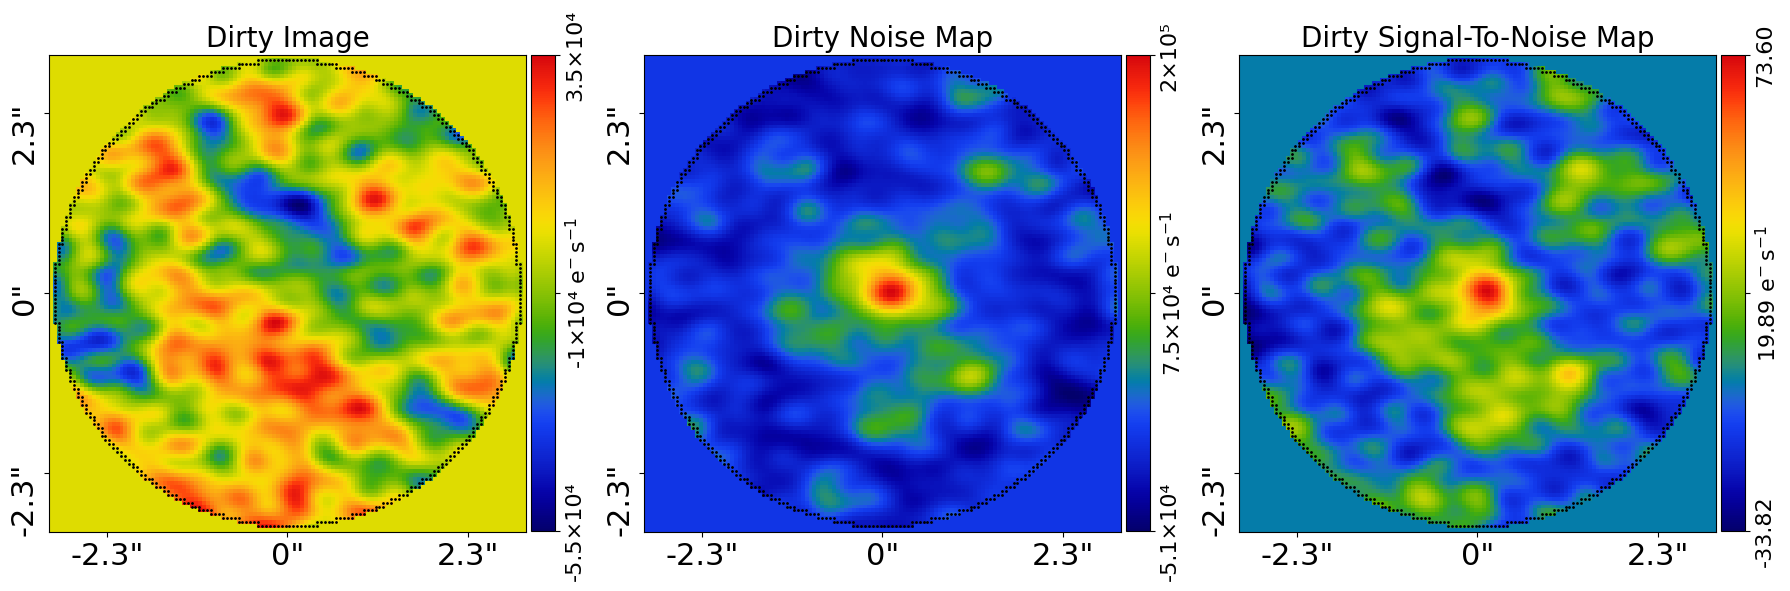

In [3]:
mocks = Path("mocks")
truths = json.loads((mocks / "truths.json").read_text())

real_space_mask = al.Mask2D.circular(
    shape_native=(256, 256), pixel_scales=0.05, radius=3.0,
)
dataset = al.Interferometer.from_fits(
    data_path=mocks / "data.fits",
    noise_map_path=mocks / "noise_map.fits",
    uv_wavelengths_path=mocks / "uv_wavelengths.fits",
    real_space_mask=real_space_mask,
    transformer_class=al.TransformerDFT,
)
print(f"Dataset:           {type(dataset).__name__}")
print(f"Visibilities:      {dataset.data.shape}")
print(f"uv-wavelengths:    {dataset.uv_wavelengths.shape}")
print(f"Real-space mask:   {real_space_mask.shape_native} @ {real_space_mask.pixel_scales} arcsec/px")
print(f"Truth lens θ_E:    {truths['lens']['einstein_radius']}\"")
print(f"Truth source R_e:  {truths['source']['effective_radius']}\"")

aplt.subplot_interferometer_dirty_images(dataset=dataset)

## 2. Fit (skip-guard)

14 free parameters at `n_live=150` on 190 visibilities is fast — a few minutes on 32 cores. As with the imaging examples, `LTA_RUN_HEAVY=1` opt-in to force a local re-fit, otherwise load the committed Cannon result.

In [4]:
_HAVE = (RESULTS_ROOT / "interferometer_basic" / "summary.json").exists()
_FORCE = os.environ.get("LTA_RUN_HEAVY", "").lower() in ("1", "true", "yes")

if _HAVE and not _FORCE:
    print("[fit] Loading committed Cannon result.")
    show_result("interferometer_basic")
    result = None
elif not _HAVE and not _FORCE:
    print("[fit] No committed results yet.")
    print("[fit] Submit via fit_example_interferometer_basic.py --part direct")
    print("[fit] or set LTA_RUN_HEAVY=1 to run locally (~5-15 min).")
    result = None
else:
    mass = af.Model(al.mp.Isothermal)
    mass.centre.centre_0 = af.GaussianPrior(mean=0.0, sigma=0.1)
    mass.centre.centre_1 = af.GaussianPrior(mean=0.0, sigma=0.1)
    mass.einstein_radius = af.UniformPrior(lower_limit=0.5, upper_limit=3.0)
    mass.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
    mass.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
    shear = af.Model(al.mp.ExternalShear)
    shear.gamma_1 = af.GaussianPrior(mean=0.0, sigma=0.1)
    shear.gamma_2 = af.GaussianPrior(mean=0.0, sigma=0.1)
    lens = af.Model(al.Galaxy, redshift=0.5, mass=mass, shear=shear)

    src_b = af.Model(al.lp.SersicCore)
    src_b.centre.centre_0 = af.GaussianPrior(mean=0.0, sigma=0.3)
    src_b.centre.centre_1 = af.GaussianPrior(mean=0.0, sigma=0.3)
    src_b.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
    src_b.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
    src_b.intensity = af.LogUniformPrior(lower_limit=1e-3, upper_limit=10.0)
    src_b.effective_radius = af.UniformPrior(lower_limit=0.1, upper_limit=3.0)
    src_b.sersic_index = af.UniformPrior(lower_limit=0.5, upper_limit=4.0)
    source = af.Model(al.Galaxy, redshift=1.0, bulge=src_b)

    model = af.Collection(galaxies=af.Collection(lens=lens, source=source))
    print(f"Free params: {model.prior_count}")

    analysis = al.AnalysisInterferometer(dataset=dataset, use_jax=False)
    search = af.Nautilus(
        path_prefix=Path("output") / "interferometer_basic",
        name="interferometer_basic",
        unique_tag="direct_iso_shear_sersic",
        n_live=150, n_batch=50, iterations_per_update=5000,
        number_of_cores=int(os.environ.get("SLURM_CPUS_PER_TASK", "1")),
    )
    result = search.fit(model=model, analysis=analysis)
    print("[fit] Done.")
    print(result.info)

[fit] No committed results yet.
[fit] Submit via fit_example_interferometer_basic.py --part direct
[fit] or set LTA_RUN_HEAVY=1 to run locally (~5-15 min).


## 3. Audit

The visibility-fit audit differs from the imaging audit in a few ways:

- **No pixel residual map.** The residuals live in the *visibility plane* — per-baseline real and imag residuals normalised by the per-visibility noise.
- **Dirty image is informative but not the residual.** `aplt.subplot_interferometer_dirty_images` shows the inverse-FFT of the data and the model — useful for visual inspection but the *true* fit-quality metric is the visibility chi².
- **Source-plane reconstruction.** Same as imaging — `aplt.subplot_galaxies` of the max-likelihood instance shows the recovered source.

### Verdict template

```
Verdict: PASS | SUSPECT | FAIL

Numeric summary
  log_evidence:    ____
  max log-lik:     ____
  visibility chi²: ____   (autolens reports this internally)

Recovery vs truth (truth value in parens)
  θ_E:        _.___ (1.6)
  shear γ:    (_.___, _.___) (0.05, 0.05)
  source R_e: _.___ (1.0)
  source n:   _.__ (2.5)
```

*Worked verdict pending Cannon results.*

## 4. Exercises

1. **Pixelised source.** Replace the SersicCore with `RectangularAdaptImage` (mirror compound_lens 03 PIX). The dirty-beam sidelobes propagate into the source-plane inversion in a non-trivial way — compare the recovered source structure vs. parametric.
2. **MGE source.** Swap the parametric source for an MGE (`al.model_util.mge_model_from(total_gaussians=20)`). The autolens 2026.4+ workflow for ALMA-class data uses MGE source as canonical.
3. **NUFFT vs DFT.** Re-fit with `transformer_class=al.TransformerNUFFT`. Wall-time should drop ~3-10× even at SMA resolution — at ALMA scale (10⁵+ visibilities) NUFFT is essential.
4. **uv-coverage swap.** The autolens_workspace ships `alma.fits` (much higher visibility count). Re-generate the mock and time the fit. JAX-on-GPU becomes essential here.
5. **Imaging vs interferometer.** Generate a parallel imaging mock with the same lens + source (use `al.SimulatorImaging`), fit both, compare posteriors. At SMA resolution the visibility fit will have larger error bars on small-scale source structure — that's the resolution penalty.

## References

- **Suyu+ (2009)** ApJ 711, 201 — visibility-plane lens model on a real submm-bright lens (B1608+656).
- **Hezaveh+ (2013)** ApJ 767, 132 — visibility-plane modelling foundations for ALMA.
- **Powell+ (2022)** MNRAS 516, 1808 — modern visibility-plane SLaM-style pipeline for ALMA strong lenses.
- `autolens_workspace_latest/scripts/interferometer/` — canonical reference scripts.

---

*Learning to Autolens — Examples / interferometer_basic / 01*  
*Rodrigo Córdova Rosado, Harvard CfA*